# Overview

Although diabetes is broadly classified as type 1 and type 2 diabetes, type 2 diabetes is known to be heterogeneous. Finer classifications of diabetes could aid in the personalization of diabetes treatment. 

Ahlqvist et al. recently identified 5 subtypes of diabetes with different risks of diabetic complications using:

1. glutamate decarboxylase antibody status
2. age at diagnoses
3. body mass index
4. HbA1c
5. homeostatic model assessment 2 estimates of beta-cell function
6. homeostatic model assessment 2 estimates of insulin resistance

**Objective:** Using health records from the UAB Health Systems, reproduce the 5 subtypes of diabetes identified by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

# Environment setup

Import functional packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Import cleaned and joined dataset.

In [2]:
data_path = "/data/user/brianlu/projects/precision_diabetes/COVID19_clusters/exports/features_joined_2024-07-08/features_joined.csv"
data = pd.read_csv(data_path)

data.info()

/scratch/local/ipykernel_97544/4157313030.py:2: DtypeWarning: Columns (165,185,187,188,195,196) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61681 entries, 0 to 61680
Columns: 266 entries, DE_ID to u_ketone_first_positive_diabetes_days
dtypes: float64(104), int64(13), object(149)
memory usage: 125.2+ MB


In [3]:
pd.pivot_table(data[["diabetes_type", "diabetes_encounter_type_class"]], 
                                      columns = ["diabetes_type"], 
                                      index=["diabetes_encounter_type_class"], 
                                      aggfunc=len, 
                                      fill_value = 0)

diabetes_type,Secondary,Type 1,Type 2
diabetes_encounter_type_class,,,
Emergency,9,383,12524
Inpatient,111,618,19311
Observation,0,12,234
Outpatient,74,1022,27269
Preadmit,0,0,1
Recurring,0,3,19


# Data cleaning

Remove rows with missing data in the 6 features for clustering.

In [4]:
ahlqvist_features = ["gad", "a1c", "bmi", "diabetes_age", "homa_cpeptide_b", "homa_cpeptide_ir"]

ahlqvist = data.dropna(subset = ahlqvist_features,
                           axis = 0)

pd.pivot_table(ahlqvist[["diabetes_type", "diabetes_encounter_type_class"]], 
                                      columns = ["diabetes_type"], 
                                      index=["diabetes_encounter_type_class"], 
                                      aggfunc=len, 
                                      fill_value = 0)

diabetes_type,Secondary,Type 1,Type 2
diabetes_encounter_type_class,,,
Emergency,0,1,41
Inpatient,2,15,116
Observation,0,0,1
Outpatient,2,6,201


Confirm data type and check for misssing values.

In [5]:
ahlqvist[ahlqvist_features].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 385 entries, 346 to 60909
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gad               385 non-null    float64
 1   a1c               385 non-null    float64
 2   bmi               385 non-null    float64
 3   diabetes_age      385 non-null    float64
 4   homa_cpeptide_b   385 non-null    float64
 5   homa_cpeptide_ir  385 non-null    float64
dtypes: float64(6)
memory usage: 21.1 KB


Subset patients by encounter type class. Only outpatient, inpatient, and emergency patient types have feasible numbers for clustering.

In [6]:
ahlqvist_outpatient = ahlqvist[ahlqvist["diabetes_encounter_type_class"] == "Outpatient"]
ahlqvist_inpatient = ahlqvist[ahlqvist["diabetes_encounter_type_class"] == "Inpatient"]
ahlqvist_emergency = ahlqvist[ahlqvist["diabetes_encounter_type_class"] == "Emergency"]

Patients under 18 at the time of diabetes diagnoses were removed similar to [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2).

In [7]:
ahlqvist_outpatient = ahlqvist_outpatient[ahlqvist_outpatient["diabetes_age"] >= 18]
ahlqvist_inpatient = ahlqvist_inpatient[ahlqvist_inpatient["diabetes_age"] >= 18]
ahlqvist_emergency = ahlqvist_emergency[ahlqvist_emergency["diabetes_age"] >= 18]

Remove outlier from patient groups. Outliers were defined as values greater than 5 standard deviations from the mean same as used by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

Defined function to remove outliers based on number of standard deviations from mean. 

In [8]:
# remove outliers by z score
def remove_outlier(df, feature, distance):
    upper = []
    lower = []
    
    # find upper and lower bounds that defines an outlier
    for f in feature:
        upper.append(float(df[[f]].mean() + distance * df[[f]].std()))
        lower.append(float(df[[f]].mean() - distance * df[[f]].std()))
    
    # subset df to only values within the outlier boundaries
    for i in range(len(upper)):
        df = df[(df[feature[i]] < upper[i]) & (df[feature[i]] > lower[i])]
    return df

In [9]:
# define features from which to remove outliers
features_to_clean = ["diabetes_age", "a1c", "bmi", "homa_cpeptide_b", "homa_cpeptide_ir"]

# remove outliers outpatient data and print number of rows removed
ahlqvist_outpatient_cleaned = remove_outlier(ahlqvist_outpatient, features_to_clean, 5)
rows_removed = ahlqvist_outpatient.shape[0] - ahlqvist_outpatient_cleaned.shape[0]
print(f"{rows_removed} outpatients were removed as outliers.")

# remove outliers inpatient data and print number of rows removed
ahlqvist_inpatient_cleaned = remove_outlier(ahlqvist_inpatient, features_to_clean, 5)
rows_removed = ahlqvist_inpatient.shape[0] - ahlqvist_inpatient_cleaned.shape[0]
print(f"{rows_removed} inpatients were removed as outliers.")

# remove outliers emergency patient data and print number of rows removed
ahlqvist_emergency_cleaned = remove_outlier(ahlqvist_emergency, features_to_clean, 5)
rows_removed = ahlqvist_emergency_cleaned.shape[0] - ahlqvist_emergency_cleaned.shape[0]
print(f"{rows_removed} emergency patients were removed as outliers.")

1 outpatients were removed as outliers.
2 inpatients were removed as outliers.
0 emergency patients were removed as outliers.


In [10]:
print(f"Number of outpatients: {ahlqvist_outpatient_cleaned.shape[0]}")
print(f"Number of inpatients: {ahlqvist_inpatient_cleaned.shape[0]}")
print(f"Number of emergency patients: {ahlqvist_emergency_cleaned.shape[0]}")

Number of outpatients: 207
Number of inpatients: 131
Number of emergency patients: 41


Check that feature values look reasonable.

In [11]:
ahlqvist_outpatient[ahlqvist_features].describe()

,gad,a1c,bmi,diabetes_age,homa_cpeptide_b,homa_cpeptide_ir
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.052885,8.853846,33.259615,49.197682,88.781250,4.896212
std,0.224343,2.625182,7.001028,14.594428,65.748162,5.792645
min,0.000000,4.400000,19.000000,18.375342,3.700000,0.530223
25%,0.000000,6.700000,29.750000,37.290411,38.325000,2.050589
50%,0.000000,8.150000,32.000000,50.338356,74.150000,3.355705
75%,0.000000,10.725000,38.000000,60.686301,121.725000,5.579096
max,1.000000,17.000000,60.000000,89.416438,321.600000,58.823529


In [12]:
ahlqvist_inpatient[ahlqvist_features].describe()

,gad,a1c,bmi,diabetes_age,homa_cpeptide_b,homa_cpeptide_ir
count,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,0.082707,10.327820,32.631579,47.242847,60.241353,3.942312
std,0.276480,3.129366,8.842454,14.924285,63.634299,9.201424
min,0.000000,4.500000,19.000000,19.627397,6.100000,0.549149
25%,0.000000,7.700000,28.000000,36.402740,22.000000,1.213592
50%,0.000000,10.800000,32.000000,48.350685,39.400000,2.325581
75%,0.000000,12.600000,37.000000,58.493151,74.400000,3.816794
max,1.000000,18.600000,70.000000,78.931507,426.700000,100.000000


In [13]:
ahlqvist_emergency[ahlqvist_features].describe()

,gad,a1c,bmi,diabetes_age,homa_cpeptide_b,homa_cpeptide_ir
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,0.071429,10.966667,33.190476,48.866601,57.495238,6.218776
std,0.260661,2.589158,5.980611,11.792035,52.592659,12.770951
min,0.000000,5.500000,21.000000,25.071233,5.200000,0.705219
25%,0.000000,8.900000,29.250000,38.555479,16.800000,1.701914
50%,0.000000,10.950000,33.000000,51.373973,35.300000,3.021838
75%,0.000000,12.900000,38.000000,57.913014,82.000000,6.431217
max,1.000000,15.700000,45.000000,67.421918,222.300000,83.333333


# Outpatient clustering

Import the packages for scaling and clustering

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering

Features were scaled using `MinMaxScaler` to keep the `gad` feature binary. 

In [15]:
x = ahlqvist_outpatient_cleaned[ahlqvist_features]

x_scaled = MinMaxScaler().fit_transform(x)

Visualize clustering hierarchy. Dendrogram function was taken from the sklearn [example page](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).

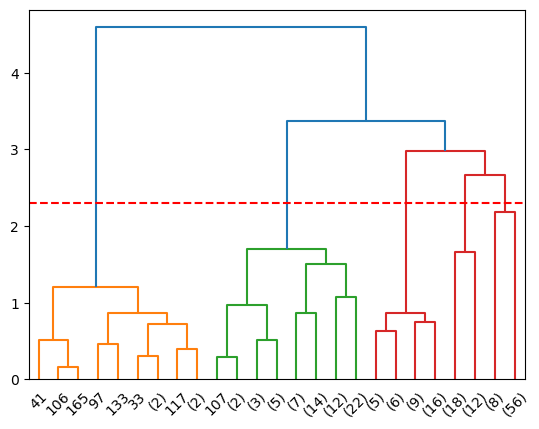

In [16]:
from scipy.cluster.hierarchy import dendrogram

clustering = AgglomerativeClustering(n_clusters = None, compute_distances = True, distance_threshold = 0).fit(x_scaled)

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
    
plot_dendrogram(clustering, truncate_mode="level", p=4)

# label approximate threshold with 5 clusters
plt.axhline(y=2.3, color='r', linestyle='--');

Also visualized silhouette scores for different number of clusters.

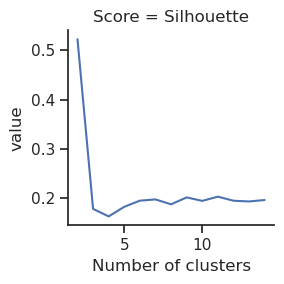

In [17]:
from sklearn.metrics import silhouette_score
# check silhouette
sil = list()
sns.set(font_scale = 1, style = "ticks")

# calculate inertia and silhouette scores for 2 to 14 clusters
for i in range(2, 15):
    clustering = AgglomerativeClustering(n_clusters = i).fit(x_scaled)
    #inertia.append(clustering.inertia_)
    sil.append(silhouette_score(x_scaled, clustering.labels_))

# organize score for graphing
outpatient_scores = pd.DataFrame({"Number of clusters": range(2, 15),
                              "Silhouette" : sil})
outpatient_scores = outpatient_scores.melt(id_vars = "Number of clusters")
outpatient_scores = outpatient_scores.rename(columns = {"variable": "Score"})

# visualize
g = sns.FacetGrid(outpatient_scores, col = "Score", sharey = False)
g.map(sns.lineplot, "Number of clusters", "value");

Re-cluster with the same number of expected clusters as [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

In [18]:
clustering = AgglomerativeClustering(n_clusters = 5).fit(x_scaled)

In [19]:
clustering.get_params(deep=True)

{'affinity': 'deprecated',
 'compute_distances': False,
 'compute_full_tree': 'auto',
 'connectivity': None,
 'distance_threshold': None,
 'linkage': 'ward',
 'memory': None,
 'metric': None,
 'n_clusters': 5}

Identify the SAID cluster by number of gad positive patients in the cluster.

In [20]:
ahlqvist_outpatient_cleaned["clusters"] = clustering.labels_.tolist()
gad_counts = ahlqvist_outpatient_cleaned.groupby("clusters")["gad"].agg("sum")
print(gad_counts)

clusters
0     0.0
1     0.0
2     0.0
3     0.0
4    11.0
Name: gad, dtype: float64


Visualize the cluster features.

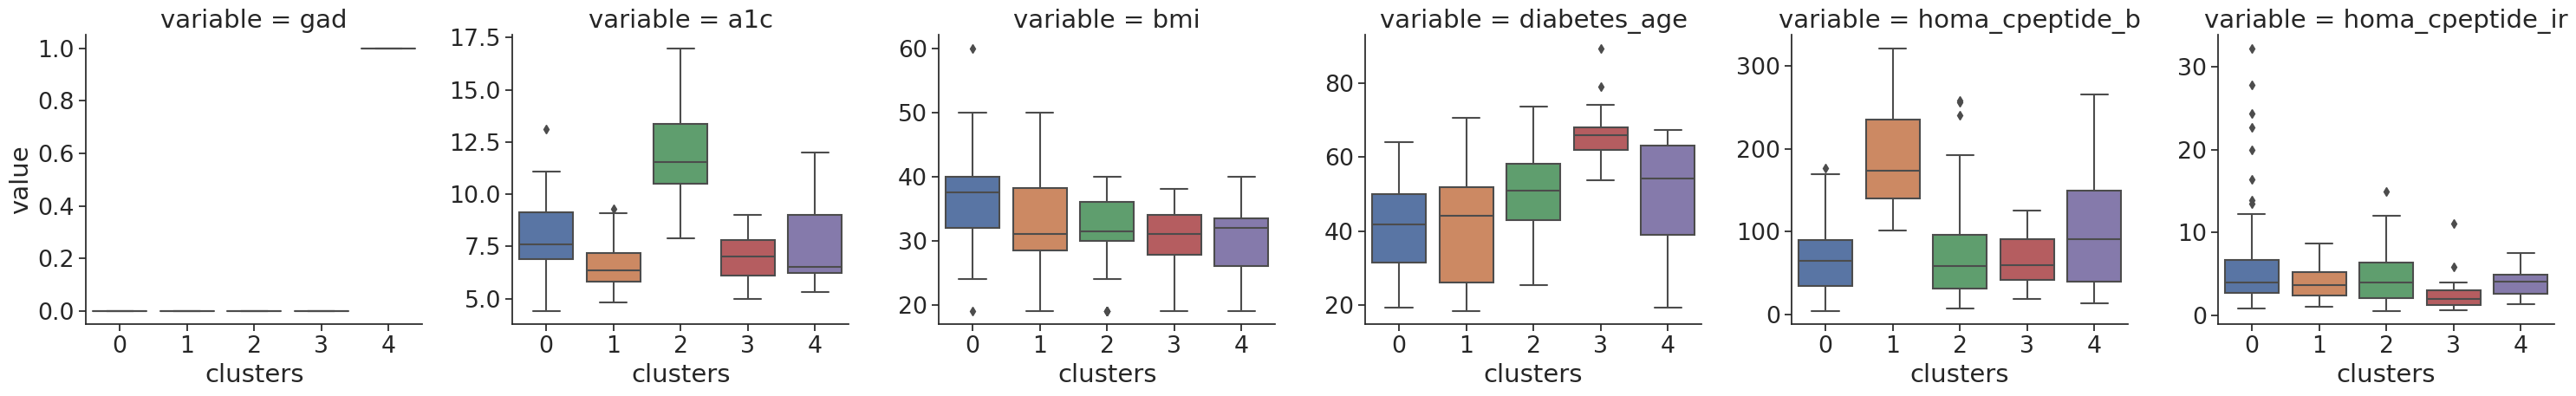

In [21]:
# convert data to long form for graphing
outpatient_long = ahlqvist_outpatient_cleaned.melt(id_vars = "clusters", 
                                                   value_vars = ahlqvist_features)

# set plot size
sns.set(font_scale = 1.75, style = "ticks")

# plot features by cluster
sns.catplot(data = outpatient_long, 
            x = "clusters", 
            y = "value", 
            col = "variable", 
            col_wrap = 6, 
            kind = "box", 
            sharey = False);

Assign cluster labels from [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2) based on features.

In [22]:
remap = {0 : "MOD", 
         1 : "SIRD",
         2 : "SIDD",
         3 : "MARD",
         4 : "SAID"}

ahlqvist_outpatient_cleaned["Ahlqvist"] = ahlqvist_outpatient_cleaned["clusters"].map(remap)
print("Number of outpatients in each cluster:")
ahlqvist_outpatient_cleaned["Ahlqvist"].value_counts()

Number of outpatients in each cluster:


SIDD    66
MOD     64
MARD    36
SIRD    30
SAID    11
Name: Ahlqvist, dtype: int64

Plot features again with cluster assignments and similar color scheme as Ahlqvist et al.

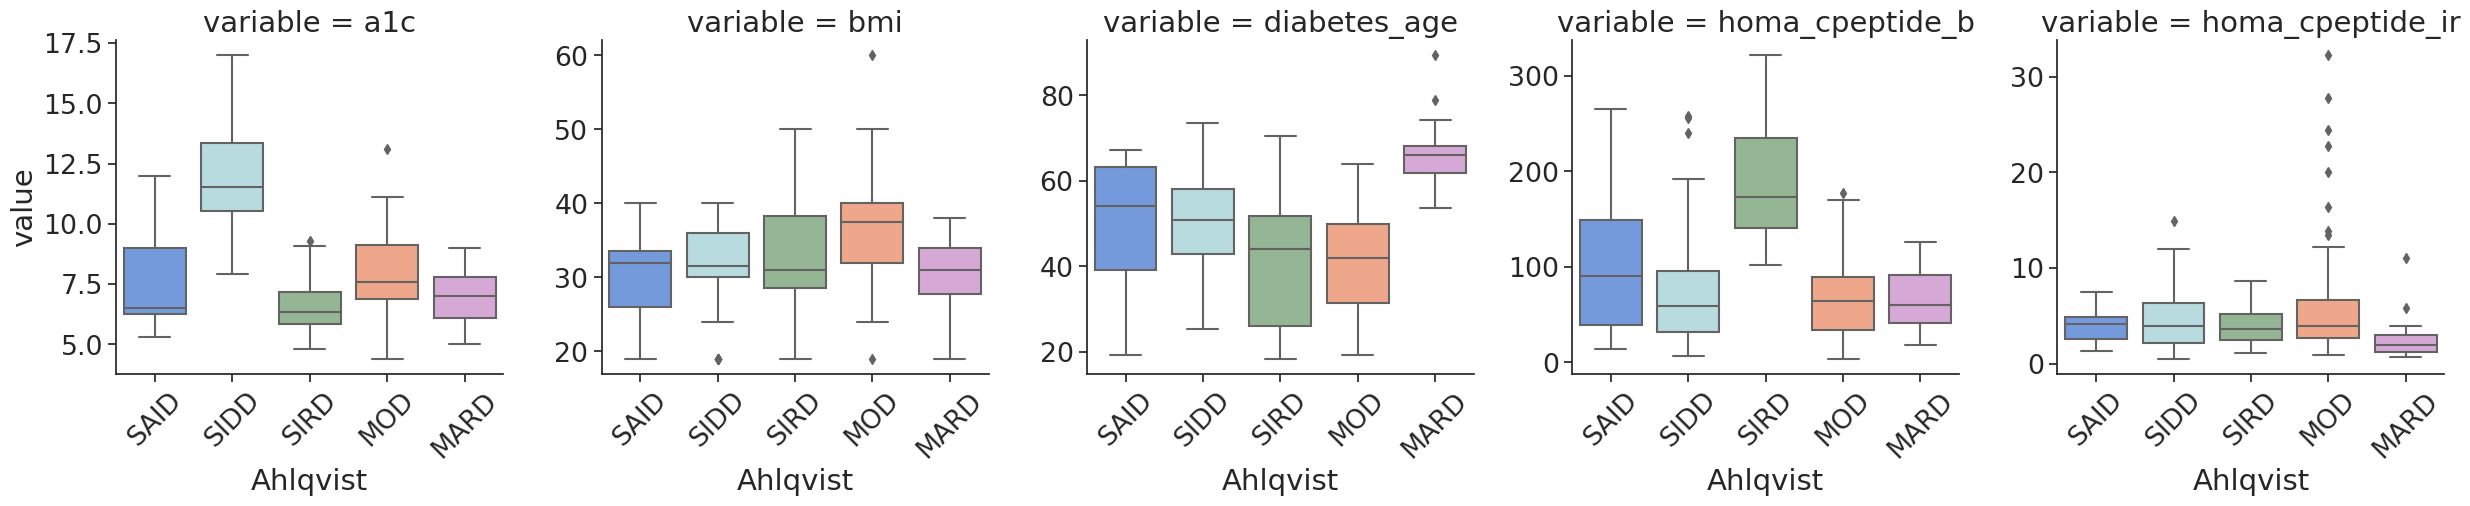

In [23]:
# convert data to long form for graphing
outpatient_long = ahlqvist_outpatient_cleaned.melt(id_vars = "Ahlqvist", 
                                                   value_vars = ["a1c", 
                                                                 "bmi", 
                                                                 "diabetes_age", 
                                                                 "homa_cpeptide_b", 
                                                                 "homa_cpeptide_ir"])

# plot features by cluster
color = ["cornflowerblue", "powderblue", "darkseagreen", "lightsalmon", "plum"]
order = ["SAID", "SIDD", "SIRD", "MOD", "MARD"]

sns.catplot(data = outpatient_long, 
            x = "Ahlqvist", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            palette = color).set_xticklabels(rotation = 45);

Cluster characteristics from outpatient cohort are similar to the Ahlqvist clusters except for SIRD not having the highest HOMA2-IR.

# Inpatient clustering

Repeat the clustering steps used for outpatients for inpatients.

In [24]:
x = ahlqvist_inpatient_cleaned[ahlqvist_features]
x_scaled = MinMaxScaler().fit_transform(x)

Visualize clustering hierarchy. Dendrogram function was taken from the sklearn [example page](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).

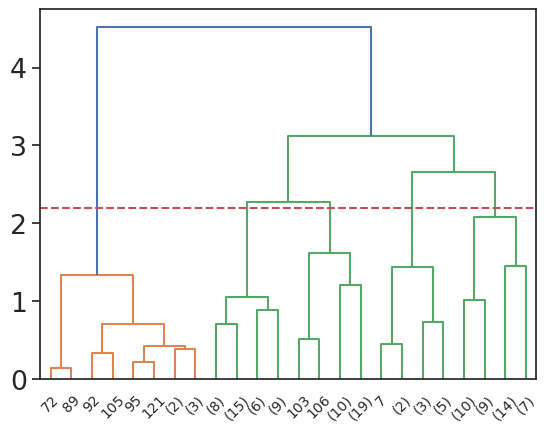

In [25]:
clustering = AgglomerativeClustering(n_clusters = None, compute_distances = True, distance_threshold = 0).fit(x_scaled)
    
plot_dendrogram(clustering, truncate_mode="level", p=4)

# label approximate threshold with 5 clusters
plt.axhline(y=2.2, color='r', linestyle='--');

Re-cluster with the same number of expected clusters as [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

In [26]:
clustering = AgglomerativeClustering(n_clusters = 5).fit(x_scaled)

In [27]:
ahlqvist_inpatient_cleaned["clusters"] = clustering.labels_.tolist()
gad_counts = ahlqvist_inpatient_cleaned.groupby("clusters")["gad"].agg("sum")
print(gad_counts)

clusters
0     0.0
1     0.0
2     0.0
3    11.0
4     0.0
Name: gad, dtype: float64


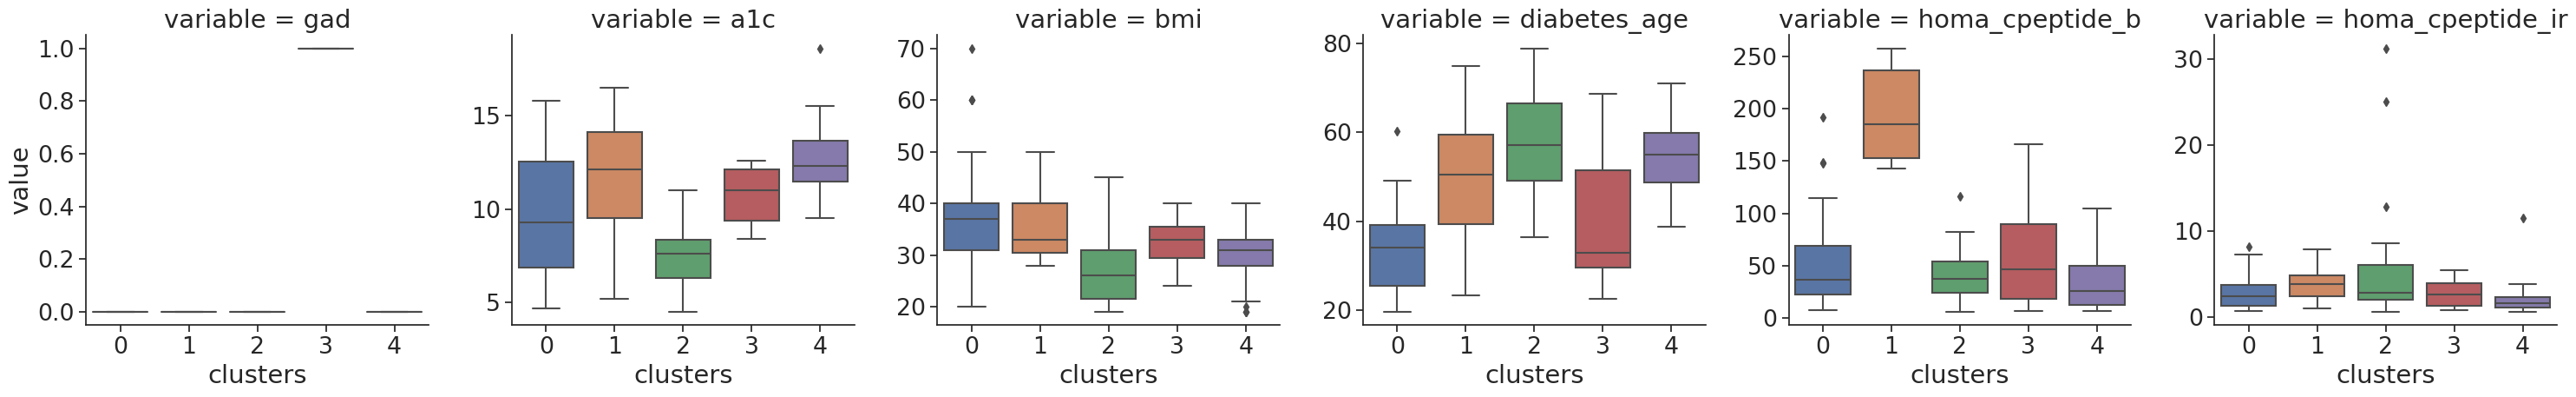

In [28]:
# convert data to long form for graphing
inpatient_long = ahlqvist_inpatient_cleaned.melt(id_vars = "clusters", 
                                                 value_vars = ahlqvist_features)

# plot features by cluster
sns.catplot(data = inpatient_long, 
            x = "clusters", 
            y = "value", 
            col = "variable", 
            col_wrap = 6, 
            kind = "box", 
            sharey = False);

In [29]:
remap = {0 : "MOD", 
         1 : "SIRD",
         2 : "MARD",
         3 : "SAID",
         4 : "SIDD"}

ahlqvist_inpatient_cleaned["Ahlqvist"] = ahlqvist_inpatient_cleaned["clusters"].map(remap)
print("Number of inpatients in each cluster:")
ahlqvist_inpatient_cleaned["Ahlqvist"].value_counts()

Number of inpatients in each cluster:


MOD     40
SIDD    38
MARD    31
SIRD    11
SAID    11
Name: Ahlqvist, dtype: int64

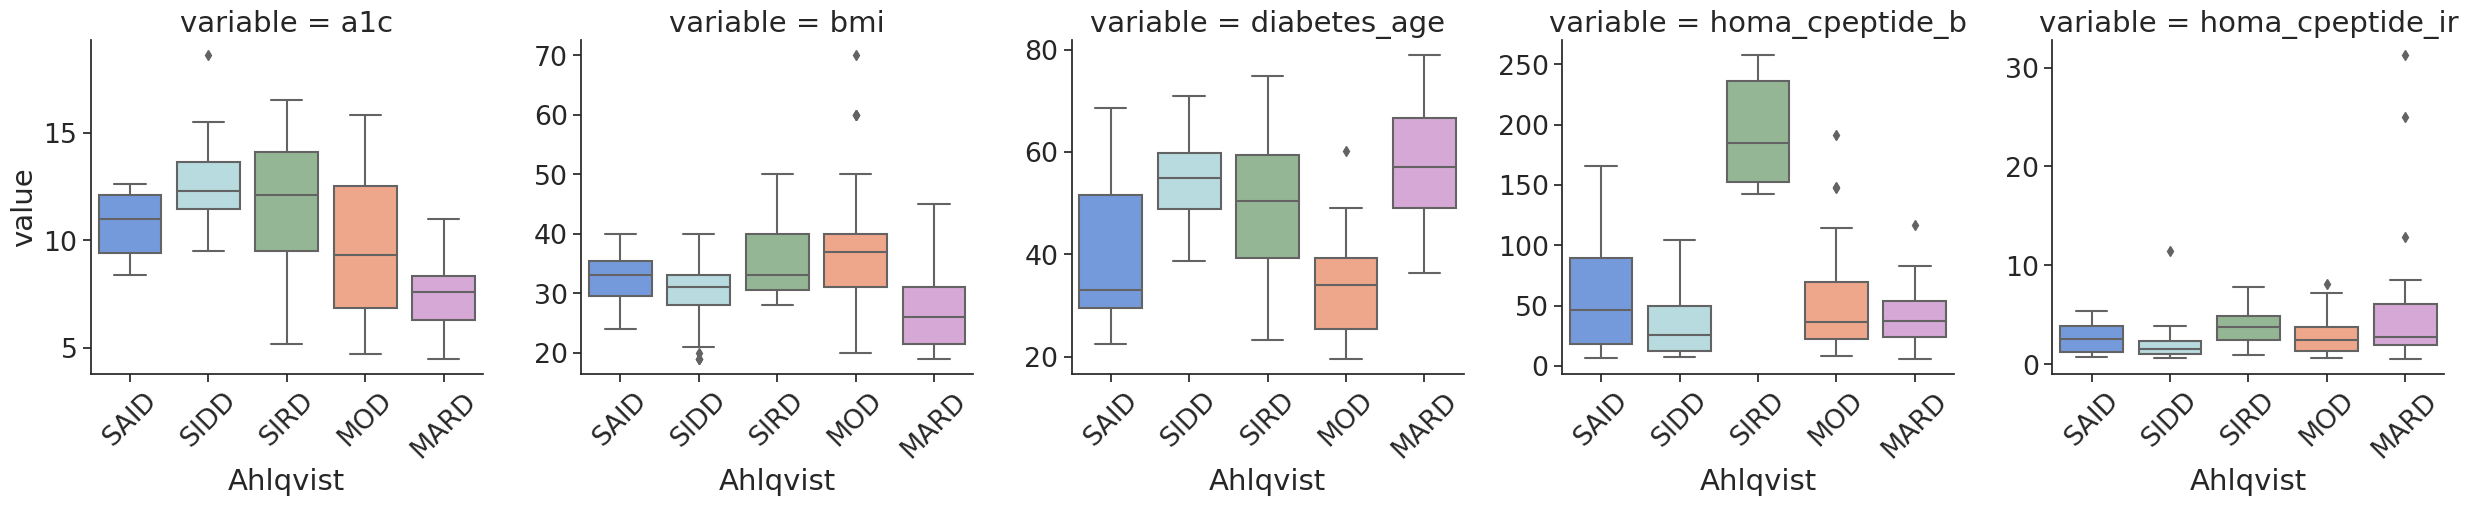

In [30]:
# convert data to long form for graphing
inpatient_long = ahlqvist_inpatient_cleaned.melt(id_vars = "Ahlqvist", 
                                                 value_vars = ["a1c", 
                                                               "bmi", 
                                                               "diabetes_age", 
                                                               "homa_cpeptide_b", 
                                                               "homa_cpeptide_ir"])

# plot features by cluster
sns.catplot(data = inpatient_long, 
            x = "Ahlqvist", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            palette = color).set_xticklabels(rotation = 45);

Inpatient clusters did not match the profile of the Ahlqvist clusters.

# Emergency patient clustering

Repeat the clustering steps used for outpatients for emergency patients.

In [31]:
x = ahlqvist_emergency_cleaned[ahlqvist_features]
x_scaled = MinMaxScaler().fit_transform(x)

Visualize clustering hierarchy. Dendrogram function was taken from the sklearn [example page](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).

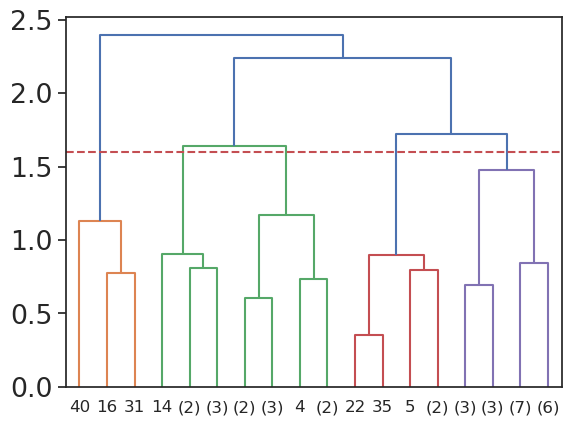

In [32]:
clustering = AgglomerativeClustering(n_clusters = None, compute_distances = True, distance_threshold = 0).fit(x_scaled)
    
plot_dendrogram(clustering, truncate_mode="level", p=4)

# label approximate threshold with 5 clusters
plt.axhline(y=1.6, color='r', linestyle='--');

Re-cluster with the same number of expected clusters as [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

In [33]:
clustering = AgglomerativeClustering(n_clusters = 5).fit(x_scaled)

In [34]:
ahlqvist_emergency_cleaned["clusters"] = clustering.labels_.tolist()
gad_counts = ahlqvist_emergency_cleaned.groupby("clusters")["gad"].agg("sum")
print(gad_counts)

clusters
0    0.0
1    3.0
2    0.0
3    0.0
4    0.0
Name: gad, dtype: float64


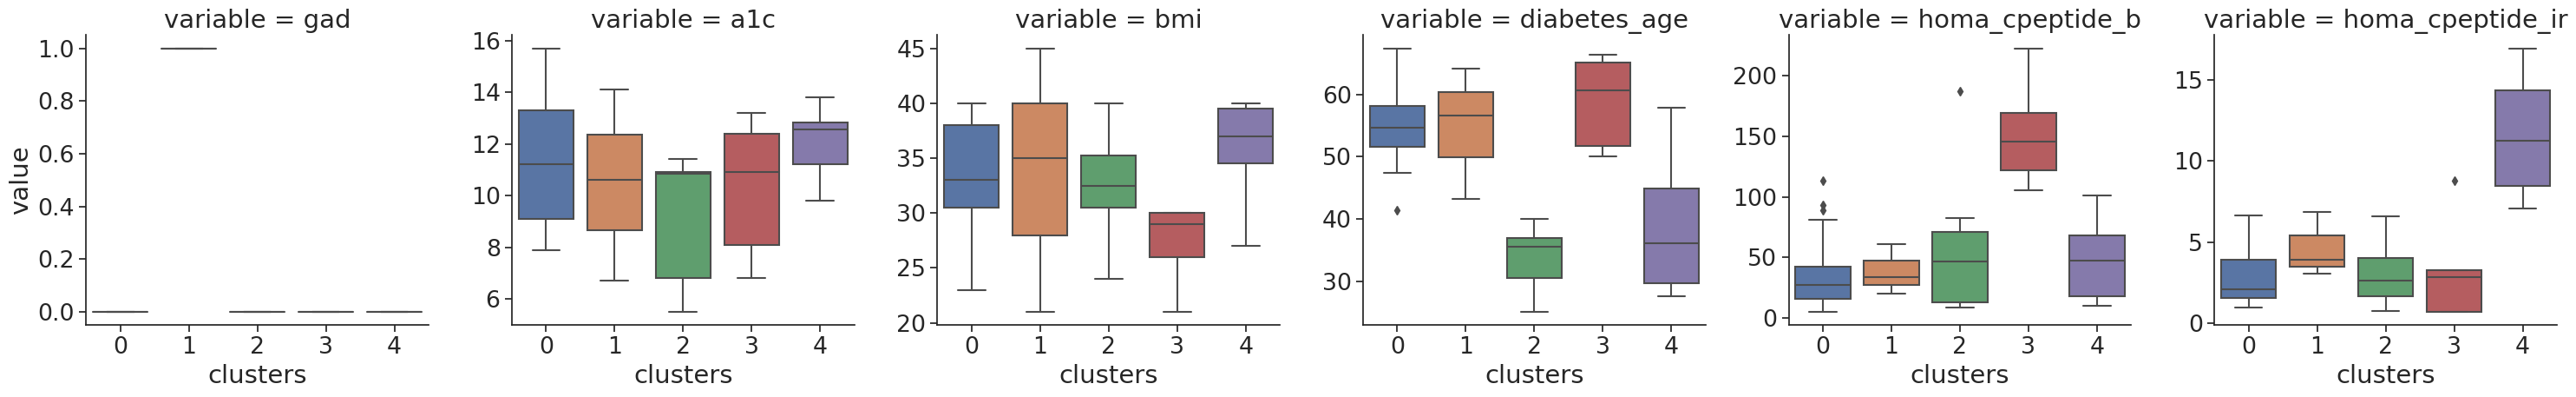

In [35]:
# convert data to long form for graphing
emergency_long = ahlqvist_emergency_cleaned.melt(id_vars = "clusters", 
                                                 value_vars = ahlqvist_features)

# plot features by cluster
sns.catplot(data = emergency_long, 
            x = "clusters", 
            y = "value", 
            col = "variable", 
            col_wrap = 6, 
            kind = "box", 
            sharey = False);

In [36]:
remap = {0 : "SIDD", 
         1 : "SAID",
         2 : "MOD",
         3 : "MARD",
         4 : "SIRD"}

ahlqvist_emergency_cleaned["Ahlqvist"] = ahlqvist_emergency_cleaned["clusters"].map(remap)
print("Number of emergency patients in each cluster:")
ahlqvist_emergency_cleaned["Ahlqvist"].value_counts()

Number of emergency patients in each cluster:


SIDD    19
MOD      8
SIRD     6
MARD     5
SAID     3
Name: Ahlqvist, dtype: int64

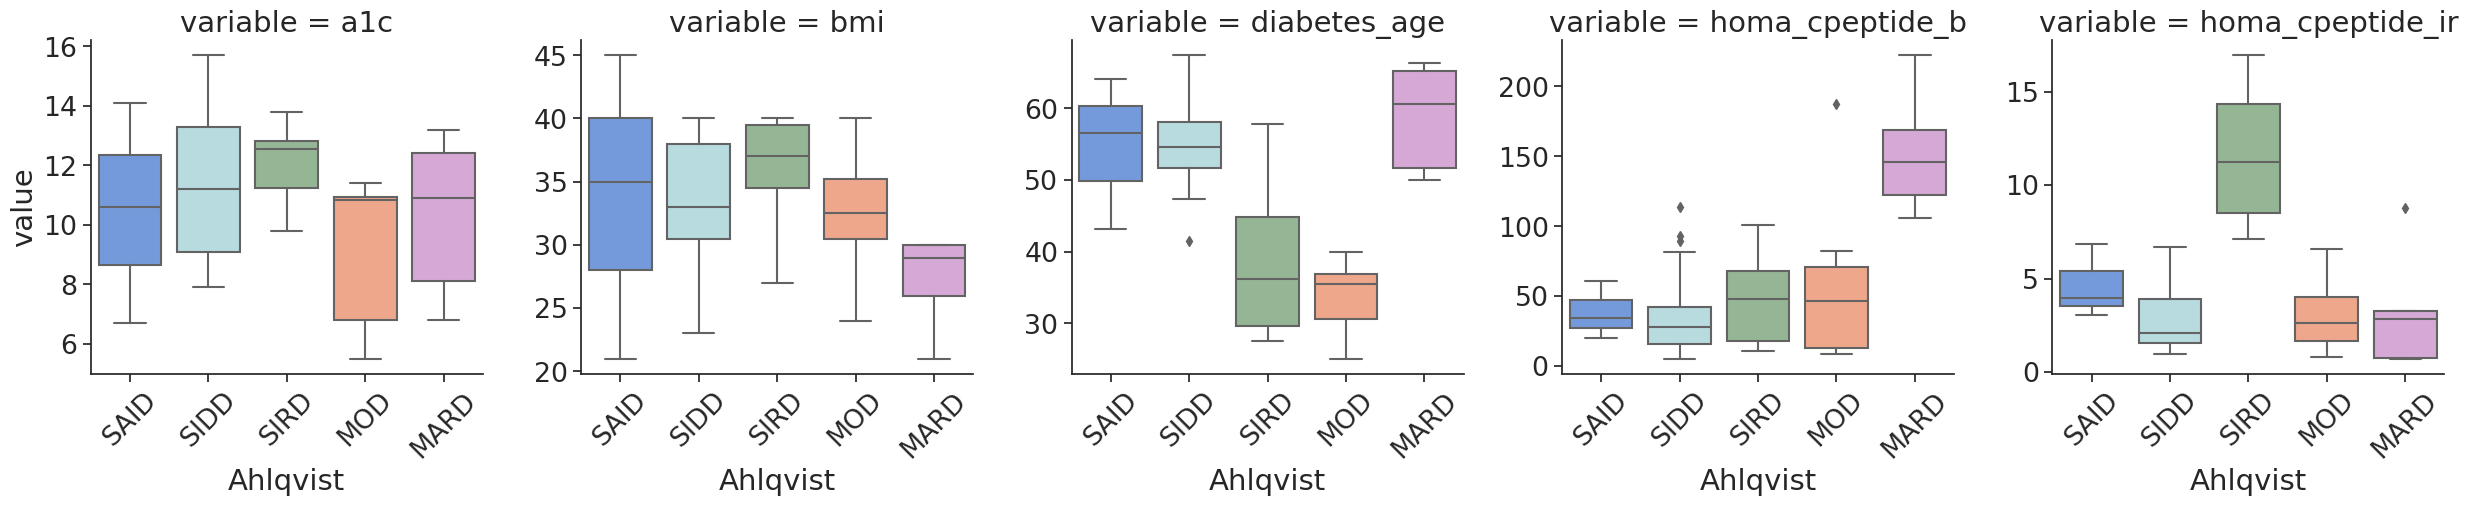

In [37]:
# convert data to long form for graphing
emergency_long = ahlqvist_emergency_cleaned.melt(id_vars = "Ahlqvist", 
                                                 value_vars = ["a1c", 
                                                               "bmi", 
                                                               "diabetes_age", 
                                                               "homa_cpeptide_b", 
                                                               "homa_cpeptide_ir"])

# plot features by cluster
sns.catplot(data = emergency_long, 
            x = "Ahlqvist", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            palette = color).set_xticklabels(rotation = 45);

Emergency patient clusters did not match the profile of the Ahlqvist clusters.

# Export clusters

In [38]:
import datetime
import os

# append export date
date = str(datetime.date.today())

# define export directory
export_dir_path = "/data/user/brianlu/projects/precision_diabetes/COVID19_clusters/exports/clustering_Ahlqvist_" + date + "/"

# create export directory if folder doesn't exist
if not os.path.isdir(export_dir_path):
    os.mkdir(export_dir_path)

# export outpatient and inpatient cluster data
ahlqvist_outpatient_cleaned.to_csv(export_dir_path + "clustering_outpatient_cleaned.csv", index = False)
ahlqvist_inpatient_cleaned.to_csv(export_dir_path + "clustering_inpatient_cleaned.csv", index = False)
ahlqvist_emergency_cleaned.to_csv(export_dir_path + "clustering_emergency_cleaned.csv", index = False)